In [2]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, DotProduct, ConstantKernel
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# 獲得関数

In [3]:
"""This function returns aquisition function and the index where its maximum value is obtained."""
def aq(mu, sigma, N):
    a = mu+3*sigma # a = mu + k * sigma
    i = np.argmax(a)
    return a, i

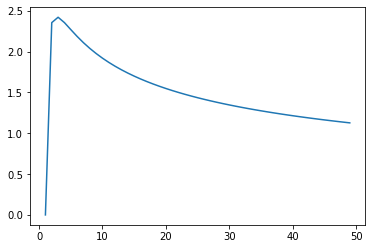

In [4]:
#上の獲得関数でkは実験回数に応じて更新することもある
fig, ax = plt.subplots()
N = np.arange(1,50)
ax.plot(N,np.sqrt(np.log(N)/N)*4)

# ベイズ最適化（1次元）

In [4]:
"""The function to be predicted"""
def f(x):
    return x*np.sin(x)

#### 初期化

In [5]:
#measured points
measured = np.array([1, 3, 5, 6, 9.5, 10])
#reset measurement
suggested = np.array([])
x = measured
print("measured", x)
print("suggested", suggested)

measured [ 1.   3.   5.   6.   9.5 10. ]
suggested []


#### 以下コードの繰り返し

2 Newly measured points: 
Newly measured at x= 1.8000000000000003


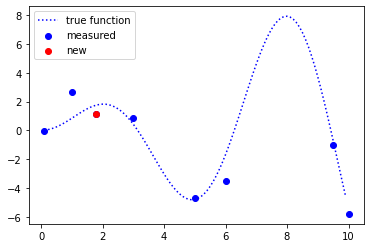

Kernel:  2.59**2 * RBF(length_scale=1.71) + WhiteKernel(noise_level=3)


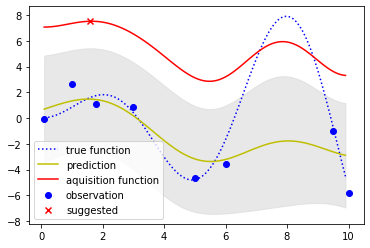

Suggested point is x= 1.6


In [24]:
np.random.seed(3)

#########################################  Observation  ############################################################
x = np.append(measured, suggested)
y = f(x)+np.random.standard_normal(len(x))

fig, ax = plt.subplots()
X = np.arange(0.1,10,0.1)
ax.plot(X, f(X), 'b:', label="true function",)
ax.scatter(x,y, label="measured", color='b')
print(len(suggested), "Newly measured points: ")
if suggested.size > 0:
    print("Newly measured at x=", suggested[-1])
    ax.scatter(x[-1],y[-1], label="new", color='r')
ax.legend()
plt.show()

#########################################  Gaussian process regression ##############################################

# set kernel
kernel = ConstantKernel()*RBF(length_scale_bounds=[0.5, 10])+WhiteKernel(noise_level_bounds=[0.01, 3])
# generate Gaussian process model instance 
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25)
# fit (tune hyperparameters in kernel)
gp.fit(x[:, np.newaxis], y[:, np.newaxis])
print("Kernel: ", gp.kernel_)

# predict y and sigma over experimental space
# namely, calcuate posteriori p(y*|measured)
y_pred, sigma = gp.predict(X[:, np.newaxis], return_std=True)

fig, ax = plt.subplots()
y_lower = y_pred.reshape(1,-1)[0]-1.96*sigma.reshape(1,-1)[0]
y_upper = y_pred.reshape(1,-1)[0]+1.96*sigma.reshape(1,-1)[0]
ax.fill_between(X, y_lower, y_upper, alpha=0.5, color='lightgray')
ax.plot(X, f(X), 'b:', label='true function')
ax.plot(X, y_pred, color='y', label='prediction')
ax.scatter(x, y, color='b', label='observation', zorder=2)

#########################################  Suggest next point #######################################################
# calculate aquisition function
a, i = aq(y_pred[:,0], sigma, len(x))
ax.plot(X, a, label='aquisition function', color='r')
ax.scatter(X[i], a[i], label="suggested", color='r', marker='x')
ax.legend()
plt.show()

suggested = np.append(suggested, X[i])
print("Suggested point is x=", suggested[-1])

# ベイズ最適化（2次元）

In [8]:
"""The function to be predicted"""
def g(X,Y):
    u = 2*np.exp(-7*((X+0.5)**2+(Y+0.5)**2-(X+0.5)*(Y+0.5)))
    v = 3*np.exp(-5*((X-0.3)**2+(Y-0.5)**2-(X-0.3)*(Y-0.5)))
    w = np.exp(-3*((X-0.6)**2+(Y+0.6)**2-(X-0.6)*(Y+0.6)))
    return -X**2-Y**2
    #return u+v+w

#### 初期化

In [9]:
#measured points
D_measured = np.array([[-0.7, -0.7],
                    [-0.7, 0.7],
                    [0.7, -0.7],
                    [0.7, 0.7],
                    [0,0]])
NP = np.array([[0,0]])
NP = np.delete(NP, 0, 0)
print("Reset NP:", NP)
print(D_measured)

Reset NP: []
[[-0.7 -0.7]
 [-0.7  0.7]
 [ 0.7 -0.7]
 [ 0.7  0.7]
 [ 0.   0. ]]


#### 以下コードの繰り返し

11 Newly measured points: 
The latest data measured at x= [0.95 0.95]
Kernel:  1.12**2 * RBF(length_scale=0.5) + WhiteKernel(noise_level=1e-05)


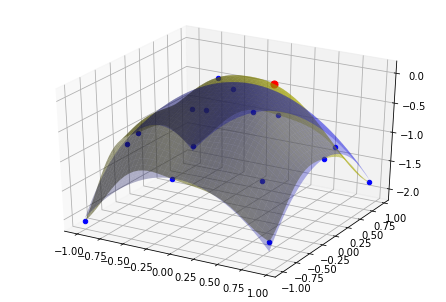

Suggested point NP is (0.200000,0.400000)


In [23]:
#%matplotlib notebook
print(NP.shape[0], "Newly measured points: ")
if NP.shape[0] > 0:
    print("The latest data measured at x=", NP[-1])


#########################################  Observation  ############################################################
D_train = np.vstack((D_measured, NP))
np.random.seed(3)
Z_train = np.zeros(len(D_train))
for i in range(0,len(D_train)):
    Z_train[i] = g(D_train[i][0], D_train[i][1])+np.random.standard_normal(1)*0.1

#########################################  Gaussian process regression ##############################################
kernel = ConstantKernel()*RBF(length_scale_bounds=[0.01, 0.5])+WhiteKernel(noise_level_bounds=[1e-5, 0.5])
GP = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20)#n_restarts_optimizer avoids falling in local maxima
GP.fit(D_train, Z_train)
print("Kernel: ", GP.kernel_)

#predict points
X1 = np.arange(-1, 1, 0.05)
X2 = np.arange(-1, 1, 0.05)
#meshgrid for 3D plot
X1X1, X2X2 = np.meshgrid(X1, X2, indexing='ij')
#X1X2 is argument for GP
X1X2 = np.c_[X1X1.flatten(), X2X2.flatten()]
G, SD = GP.predict(X1X2, return_std=True)
G_mesh = G.reshape((len(X1), len(X2)))#mesh for 3D plot

fig = plt.figure()
ax = Axes3D(fig)
ax.plot_surface(X1X1, X2X2, G_mesh, rstride=1, cstride=1, alpha=0.5, color='y')#prediction
for i in range(0, len(D_train)):
    ax.scatter(D_train[i][0], D_train[i][1], Z_train[i], color='b')

#calculate true function
Z_true = np.zeros(len(X1X2))
for i in range(0,len(X1X2)):
    Z_true[i] = g(X1X2[i][0], X1X2[i][1])
Z_true_mesh = Z_true.reshape((len(X1), len(X2)))
ax.plot_surface(X1X1, X2X2, Z_true_mesh, rstride=1, cstride=1, alpha=0.3, color='b')#true function

#########################################  Suggest next point #######################################################
# evaluate aquisition function
A, index = aq(G, SD, len(X1X2))
A_mesh = A.reshape((len(X1), len(X2)))
indices = np.argwhere(A_mesh==A[index])#the location of maximum Aq
NP_x1 = X1[indices[0][0]]
NP_x2 = X2[indices[0][1]]
ax.scatter(NP_x1, NP_x2, G[index], color='r', s=50)
plt.show()

print("Suggested point NP is (%f,%f)" %(NP_x1, NP_x2))
NP = np.vstack((NP, [NP_x1, NP_x2]) )#add the suggested point to NP

#### 予測分布・元の関数・獲得関数のコンタ―図

Suggested point NP is (-0.050000,0.950000)


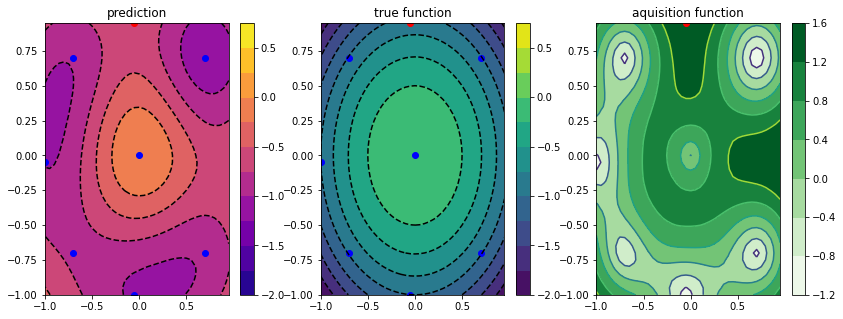

In [14]:
print("Suggested point NP is (%f,%f)" %(NP_x1, NP_x2))
levels = np.arange(np.around(np.min(G_mesh))-1, np.around(np.max(G_mesh))+1, 0.25)
fig, ax = plt.subplots(figsize=(14, 5), ncols=3)

cs_pred = ax[0].contourf(X2X2, X1X1, G_mesh, levels=levels, cmap=cm.plasma)
ax[0].contour(cs_pred, colors='k')
ax[0].set_title("prediction")
ax[0].scatter(D_train[:,0], D_train[:,1], color='b')
ax[0].scatter(NP_x1, NP_x2, color='r')
cs_true = ax[1].contourf(X2X2, X1X1, Z_true_mesh, levels=levels)
ax[1].contour(cs_true, colors='k')
ax[1].scatter(D_train[:,0], D_train[:,1], color='b')
ax[1].scatter(NP_x1, NP_x2, color='r')
ax[1].set_title("true function")
fig.colorbar(cs_pred, ax=ax[0])
fig.colorbar(cs_true, ax=ax[1])
cs_aq = ax[2].contourf(X2X2, X1X1, A_mesh, cmap='Greens')
ax[2].contour(cs_aq)
ax[2].set_title("aquisition function")
ax[2].scatter(NP_x1, NP_x2, color='r')
fig.colorbar(cs_aq, ax=ax[2])
plt.show()

# ベイズ最適化（n次元）

In [317]:
"""The function to be predicted"""
def h(Array):
    X = Array[0]
    Y = Array[1]
    Z = Array[2]
    
    #2次関数
    #u = -(X-0.5)**2-(Y-0.25)**2-(Z-0.5)**2
    #v = -2*(X**2+Y**2+Z**2)
    
    #正規分布的な関数
    u = 2*np.exp(-5*((X+0.5)**2+(Y+0.5)**2))
    v = 5*np.exp(-5*((X-0.3)**2+(Y-0.5)**2))
    w = np.exp(-3*((Z-0.6)**2+(Y+0.6)**2))
    return u+v+w

#### 初期化

In [318]:
#measured points
D_measured = np.array([[-1, -1, -1],
                    [-1, -1, 1],
                    [-1, 1, -1],
                    [1, -1, -1],
                    [1, -1, 1],
                    [0, 0, 0]])
NP = np.array([[0, 0, 0]])
NP = np.delete(NP, 0, 0)
print("Reset NP:", NP)

Reset NP: []


#### 以下コードの繰り返し
maxN:繰返しの数

In [319]:
maxN = 50
Z_record = np.array([])

for i in range(0, maxN):
    if NP.shape[0] > 0:
        print("Measurement point %d at x=%s" %(i, NP[-1]))

    #########################################  Observation  ############################################################
    D_train = np.vstack((D_measured, NP))
    np.random.seed(3)
    Z_train = np.zeros(len(D_train))
    for i in range(0,len(D_train)):
        Z_train[i] = h(D_train[i])+np.random.standard_normal(1)*0.1

    #########################################  Gaussian process regression ##############################################
    kernel = ConstantKernel()*RBF(length_scale_bounds=[0.1, 1])+WhiteKernel(noise_level_bounds=[1e-4, 0.1])
    GP = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25)#n_restarts_optimizer
    GP.fit(D_train, Z_train)
    print("Kernel: ", GP.kernel_)

    #predict points
    X1 = np.arange(-1, 1, 0.025)
    X2 = np.arange(-1, 1, 0.025)
    X3 = np.arange(-1, 1, 0.025)

    X1X1, X2X2, X3X3 = np.meshgrid(X1, X2, X3, indexing='ij')
    X1X2X3 = np.c_[X1X1.flatten(), X2X2.flatten(), X3X3.flatten()]
    G, SD = GP.predict(X1X2X3, return_std=True)

    #########################################  Suggest next point #######################################################
    # evaluate aquisition function
    A, index = aq(G, SD, len(X1X2X3))
    A_mesh = A.reshape((len(X1), len(X2), len(X3)))
    indices = np.argwhere(A_mesh==A[index])#the location of maximum aquisition function
    NP_x1 = X1[indices[0][0]]
    NP_x2 = X2[indices[0][1]]
    NP_x3 = X3[indices[0][2]]
    NP = np.vstack((NP, [NP_x1, NP_x2, NP_x3]) )#add the suggested point to NP
    Z_record = np.append(Z_record, Z_train[-1])

Kernel:  0.54**2 * RBF(length_scale=1) + WhiteKernel(noise_level=0.0001)
Measurement point 1 at x=[-0.175  0.35   0.975]
Kernel:  0.614**2 * RBF(length_scale=1) + WhiteKernel(noise_level=0.0001)
Measurement point 2 at x=[0.65  0.825 0.675]
Kernel:  0.635**2 * RBF(length_scale=1) + WhiteKernel(noise_level=0.0001)
Measurement point 3 at x=[-0.175  0.975  0.45 ]
Kernel:  0.635**2 * RBF(length_scale=1) + WhiteKernel(noise_level=0.0845)
Measurement point 4 at x=[0.575 0.2   0.975]
Kernel:  0.801**2 * RBF(length_scale=0.981) + WhiteKernel(noise_level=0.0001)
Measurement point 5 at x=[0.975 0.125 0.475]
Kernel:  0.791**2 * RBF(length_scale=0.769) + WhiteKernel(noise_level=0.1)
Measurement point 6 at x=[ 0.15  -0.225  0.975]
Kernel:  0.758**2 * RBF(length_scale=0.683) + WhiteKernel(noise_level=0.1)
Measurement point 7 at x=[0.4   0.525 0.975]
Kernel:  1.39**2 * RBF(length_scale=0.373) + WhiteKernel(noise_level=0.1)
Measurement point 8 at x=[0.275 0.475 0.75 ]
Kernel:  1.51**2 * RBF(length_scal

#### 実験範囲の関数の最大値を計算（総当たり）

In [320]:
X1_ = np.arange(-1, 1, 0.1)
X2_ = np.arange(-1, 1, 0.1)
X3_ = np.arange(-1, 1, 0.1)

X1X1_, X2X2_, X3X3_ = np.meshgrid(X1_, X2_, X3_, indexing='ij')
X1X2X3_ = np.c_[X1X1_.flatten(), X2X2_.flatten(), X3X3_.flatten()]

H = np.array([])
for x1x2x3_ in X1X2X3_:#ここの繰返しが時間がかかるのでX1_は粗めに設定
    H = np.append(H, h(x1x2x3_))
arg = np.argmax(H)

H_mesh = H.reshape((len(X1_), len(X2_), len(X3_)))
arg_mesh = np.argwhere(H_mesh==H[arg])
arg_x1 = X1_[arg_mesh[0][0]]
arg_x2 = X2_[arg_mesh[0][1]]
arg_x3 = X3_[arg_mesh[0][2]]

print("Maximum value of h(x,y,z)= %f at [x,y,z]=[%.3f, %.3f, %.3f]" 
      %(h([arg_x1, arg_x2, arg_x3]), arg_x1, arg_x2, arg_x3))

Maximum value of h(x,y,z)= 5.027065 at [x,y,z]=[0.300, 0.500, 0.600]


#### ベイズ最適化による値の更新

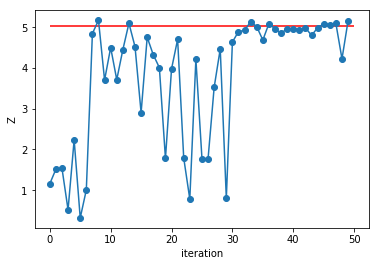

In [321]:
fig, ax = plt.subplots()
ax.plot(Z_record,'o-')
ax.set_xlabel("iteration")
ax.set_ylabel("Z")
ax.hlines(y=np.max(H), xmin=0, xmax=len(Z_record), color='r')

#### 探索した実験点の図示

In [327]:
fig = plt.figure()
ax = Axes3D(fig)
for i in range(0,len(NP)):
    ax.scatter(NP[i][0], NP[i][1], NP[i][2], color='k', marker="$"+str(i)+"$", s=100)

#### すべての組合せを得る方法

In [80]:
X1 = np.arange(-1, 1, 0.5)
X2 = np.arange(-1, 1, 0.5)
X3 = np.arange(-1, 1, 0.5)

X1X1, X2X2, X3X3 = np.meshgrid(X1, X2, X3, indexing='ij')
#X1X2 is argument for GP
X1X2X3 = np.c_[X1X1.flatten(), X2X2.flatten(), X3X3.flatten()]
X1X2X3

array([[-1. , -1. , -1. ],
       [-1. , -1. , -0.5],
       [-1. , -1. ,  0. ],
       [-1. , -1. ,  0.5],
       [-1. , -0.5, -1. ],
       [-1. , -0.5, -0.5],
       [-1. , -0.5,  0. ],
       [-1. , -0.5,  0.5],
       [-1. ,  0. , -1. ],
       [-1. ,  0. , -0.5],
       [-1. ,  0. ,  0. ],
       [-1. ,  0. ,  0.5],
       [-1. ,  0.5, -1. ],
       [-1. ,  0.5, -0.5],
       [-1. ,  0.5,  0. ],
       [-1. ,  0.5,  0.5],
       [-0.5, -1. , -1. ],
       [-0.5, -1. , -0.5],
       [-0.5, -1. ,  0. ],
       [-0.5, -1. ,  0.5],
       [-0.5, -0.5, -1. ],
       [-0.5, -0.5, -0.5],
       [-0.5, -0.5,  0. ],
       [-0.5, -0.5,  0.5],
       [-0.5,  0. , -1. ],
       [-0.5,  0. , -0.5],
       [-0.5,  0. ,  0. ],
       [-0.5,  0. ,  0.5],
       [-0.5,  0.5, -1. ],
       [-0.5,  0.5, -0.5],
       [-0.5,  0.5,  0. ],
       [-0.5,  0.5,  0.5],
       [ 0. , -1. , -1. ],
       [ 0. , -1. , -0.5],
       [ 0. , -1. ,  0. ],
       [ 0. , -1. ,  0.5],
       [ 0. , -0.5, -1. ],
 

In [79]:
X1X1.flatten()

array([-1. , -1. , -1. , -1. , -0.5, -0.5, -0.5, -0.5,  0. ,  0. ,  0. ,
        0. ,  0.5,  0.5,  0.5,  0.5, -1. , -1. , -1. , -1. , -0.5, -0.5,
       -0.5, -0.5,  0. ,  0. ,  0. ,  0. ,  0.5,  0.5,  0.5,  0.5, -1. ,
       -1. , -1. , -1. , -0.5, -0.5, -0.5, -0.5,  0. ,  0. ,  0. ,  0. ,
        0.5,  0.5,  0.5,  0.5, -1. , -1. , -1. , -1. , -0.5, -0.5, -0.5,
       -0.5,  0. ,  0. ,  0. ,  0. ,  0.5,  0.5,  0.5,  0.5])